<a href="https://colab.research.google.com/github/yoginikumar0608-gh/GenZSpace/blob/main/Facial_Emotion_Recognition_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU: []


In [7]:
from google.colab import files

uploaded = files.upload()

Saving archive (2).zip to archive (2).zip


In [9]:
import zipfile
import os

zip_file = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall('/content/emotion_dataset')

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [10]:
import os

print(os.listdir('/content/emotion_dataset'))

['train', 'val', 'test']


In [11]:
print("Train folders:")
print(os.listdir('/content/emotion_dataset/train'))

Train folders:
['Surprise', 'Sad', 'Neutral', 'Disgust', 'Happy', 'Fear', 'Angry']


In [12]:
print(os.listdir('/content/emotion_dataset'))

['train', 'val', 'test']


In [13]:
print(os.listdir('/content/emotion_dataset/train'))

['Surprise', 'Sad', 'Neutral', 'Disgust', 'Happy', 'Fear', 'Angry']


In [14]:
import tensorflow as tf

IMG_SIZE = 48
BATCH_SIZE = 64

train_dataset = tf.keras.utils.image_dataset_from_directory(
    "/content/emotion_dataset/train",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    color_mode="grayscale"
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    "/content/emotion_dataset/val",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    color_mode="grayscale"
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    "/content/emotion_dataset/test",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    color_mode="grayscale"
)

Found 28709 files belonging to 7 classes.
Found 3589 files belonging to 7 classes.
Found 3589 files belonging to 7 classes.


In [15]:
class_names = train_dataset.class_names

print("Emotion classes:")
print(class_names)

Emotion classes:
['Angry', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']


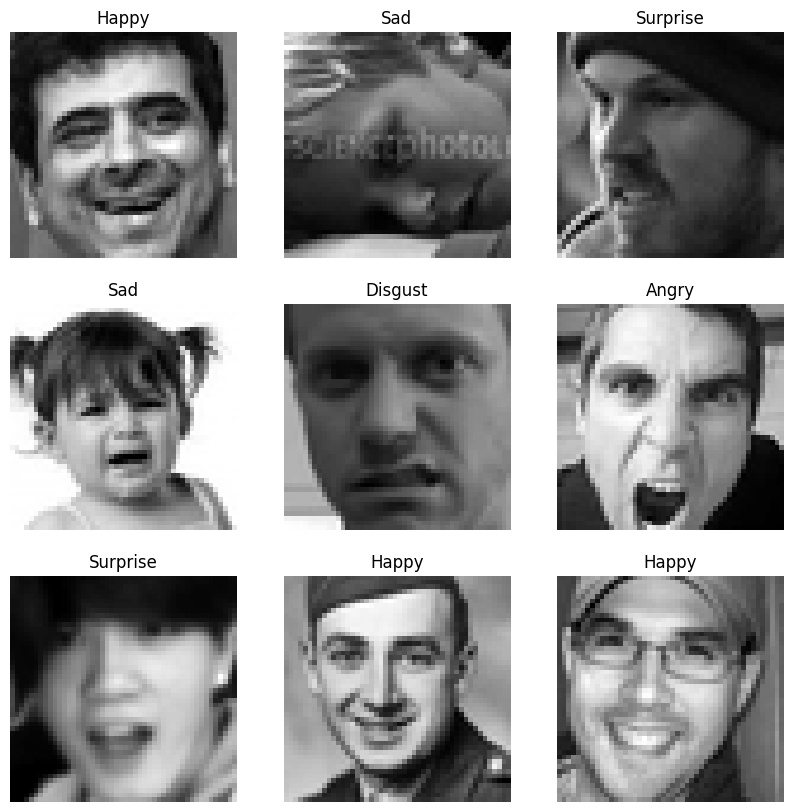

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(
            images[i].numpy().squeeze(),
            cmap="gray"
        )

        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

In [17]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_dataset = train_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

val_dataset = val_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

test_dataset = test_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

In [18]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().shuffle(1000).prefetch(
    buffer_size=AUTOTUNE
)

val_dataset = val_dataset.cache().prefetch(
    buffer_size=AUTOTUNE
)

test_dataset = test_dataset.cache().prefetch(
    buffer_size=AUTOTUNE
)

print("Dataset preparation completed!")

Dataset preparation completed!


In [19]:
model = tf.keras.Sequential([

    # Convolution Layer 1
    tf.keras.layers.Conv2D(
        32,
        (3, 3),
        activation='relu',
        input_shape=(48, 48, 1)
    ),

    # Pooling Layer 1
    tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    # Convolution Layer 2
    tf.keras.layers.Conv2D(
        64,
        (3, 3),
        activation='relu'
    ),

    # Pooling Layer 2
    tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    # Convolution Layer 3
    tf.keras.layers.Conv2D(
        128,
        (3, 3),
        activation='relu'
    ),

    # Pooling Layer 3
    tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    # Convert feature maps into one-dimensional data
    tf.keras.layers.Flatten(),

    # Fully connected layer
    tf.keras.layers.Dense(
        128,
        activation='relu'
    ),

    # Prevent overfitting
    tf.keras.layers.Dropout(0.5),

    # Output layer - 7 emotions
    tf.keras.layers.Dense(
        7,
        activation='softmax'
    )
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,847 (1.36 MB)

 Trainable params: 355,847 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("CNN model compiled successfully!")

CNN model compiled successfully!


In [22]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=5
)

Epoch 1/5
449/449 ━━━━━━━━━━━━━━━━━━━━ 103s 218ms/step - accuracy: 0.2872 - loss: 1.7542 - val_accuracy: 0.4065 - val_loss: 1.5555
Epoch 2/5
449/449 ━━━━━━━━━━━━━━━━━━━━ 95s 212ms/step - accuracy: 0.4178 - loss: 1.5116 - val_accuracy: 0.4726 - val_loss: 1.4122
Epoch 3/5
449/449 ━━━━━━━━━━━━━━━━━━━━ 95s 212ms/step - accuracy: 0.4667 - loss: 1.3926 - val_accuracy: 0.4971 - val_loss: 1.3075
Epoch 4/5
449/449 ━━━━━━━━━━━━━━━━━━━━ 95s 212ms/step - accuracy: 0.4966 - loss: 1.3194 - val_accuracy: 0.5163 - val_loss: 1.2577
Epoch 5/5
449/449 ━━━━━━━━━━━━━━━━━━━━ 142s 212ms/step - accuracy: 0.5246 - loss: 1.2595 - val_accuracy: 0.5191 - val_loss: 1.2609


In [23]:
test_loss, test_accuracy = model.evaluate(test_dataset)

print("Test Accuracy:", round(test_accuracy * 100, 2), "%")

57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - accuracy: 0.5227 - loss: 1.2521
Test Accuracy: 52.27 %


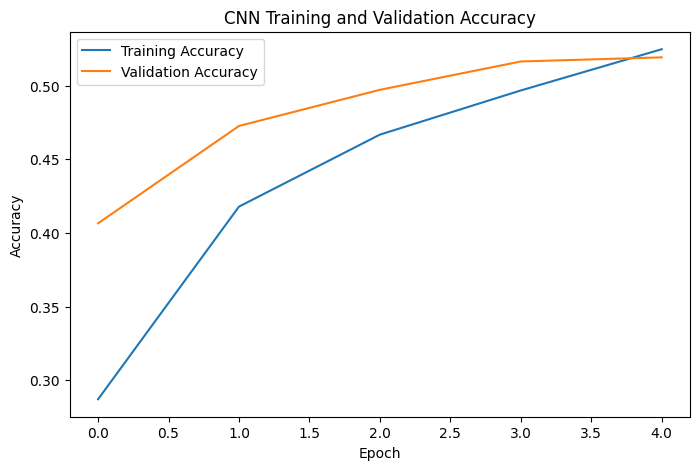

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('CNN Training and Validation Accuracy')
plt.legend()
plt.show()

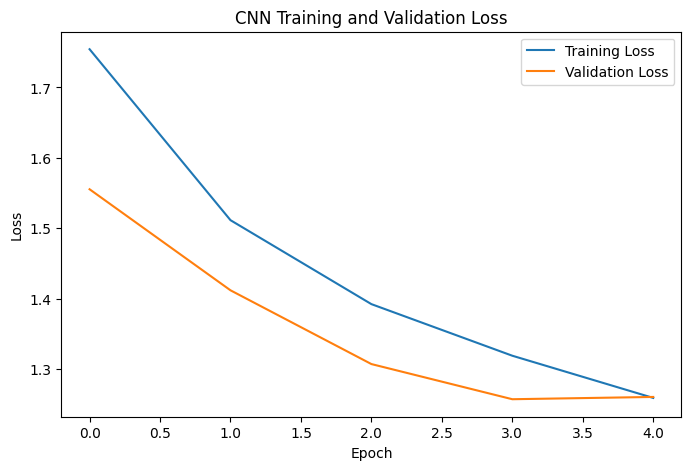

In [25]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CNN Training and Validation Loss')
plt.legend()
plt.show()

In [27]:
from google.colab import files

uploaded = files.upload()

Saving my pic.jpg to my pic (1).jpg


In [28]:
image_path = list(uploaded.keys())[0]

print("Uploaded image:", image_path)

Uploaded image: my pic (1).jpg


In [30]:
image_path = list(uploaded.keys())[0]

print("Uploaded image:", image_path)

Uploaded image: my pic (1).jpg


In [31]:
import cv2
import matplotlib.pyplot as plt

# Load the uploaded image
image = cv2.imread(image_path)

# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Load OpenCV face detector
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

# Detect faces
faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(30, 30)
)

print("Faces detected:", len(faces))

AttributeError: module 'cv2' has no attribute 'CascadeClassifier'

In [32]:
!pip uninstall -y opencv-python opencv-contrib-python opencv-python-headless
!pip install opencv-python-headless

Found existing installation: opencv-python 5.0.0.93
Uninstalling opencv-python-5.0.0.93:
  Successfully uninstalled opencv-python-5.0.0.93
Found existing installation: opencv-contrib-python 4.14.0.94
Uninstalling opencv-contrib-python-4.14.0.94:
  Successfully uninstalled opencv-contrib-python-4.14.0.94
Found existing installation: opencv-python-headless 5.0.0.93
Uninstalling opencv-python-headless-5.0.0.93:
  Successfully uninstalled opencv-python-headless-5.0.0.93
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 MB 12.4 MB/s eta 0:00:00


In [1]:
import cv2

print("OpenCV version:", cv2.__version__)
print("CascadeClassifier available:", hasattr(cv2, "CascadeClassifier"))

OpenCV version: 5.0.0
CascadeClassifier available: False


In [2]:
!pip uninstall -y opencv-python opencv-python-headless opencv-contrib-python
!pip install opencv-python==4.10.0.84

Found existing installation: opencv-python-headless 5.0.0.93
Uninstalling opencv-python-headless-5.0.0.93:
  Successfully uninstalled opencv-python-headless-5.0.0.93
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 MB 9.4 MB/s eta 0:00:00


In [1]:
import cv2

print("OpenCV version:", cv2.__version__)
print("CascadeClassifier available:", hasattr(cv2, "CascadeClassifier"))

OpenCV version: 4.10.0
CascadeClassifier available: True


In [2]:
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

print("Face detector loaded successfully!")

Face detector loaded successfully!


In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

print("OpenCV:", cv2.__version__)
print("TensorFlow:", tf.__version__)

OpenCV: 4.10.0
TensorFlow: 2.20.0


In [4]:
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

print("Face detector loaded:", not face_cascade.empty())

Face detector loaded: True


In [6]:
model = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(48, 48, 1)),

    tf.keras.layers.Conv2D(
        32, (3, 3), activation='relu'
    ),

    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(
        64, (3, 3), activation='relu'
    ),

    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(
        128, (3, 3), activation='relu'
    ),

    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(
        128, activation='relu'
    ),

    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(
        7, activation='softmax'
    )
])

print("CNN created successfully!")

CNN created successfully!


In [7]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("CNN compiled successfully!")

CNN compiled successfully!


In [9]:
import os

print(os.listdir("/content"))

['.config', 'my pic.jpg', 'my pic (1).jpg', 'emotion_dataset', 'archive (2).zip', 'sample_data']


In [10]:
print(os.listdir("/content/emotion_dataset"))

['train', 'val', 'test']


In [11]:
import tensorflow as tf

IMG_SIZE = 48
BATCH_SIZE = 64

train_dataset = tf.keras.utils.image_dataset_from_directory(
    "/content/emotion_dataset/train",
    image_size=(48, 48),
    batch_size=BATCH_SIZE,
    color_mode="grayscale"
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    "/content/emotion_dataset/val",
    image_size=(48, 48),
    batch_size=BATCH_SIZE,
    color_mode="grayscale"
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    "/content/emotion_dataset/test",
    image_size=(48, 48),
    batch_size=BATCH_SIZE,
    color_mode="grayscale"
)

print("Datasets loaded successfully!")

Found 28709 files belonging to 7 classes.
Found 3589 files belonging to 7 classes.
Found 3589 files belonging to 7 classes.
Datasets loaded successfully!


In [12]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_dataset = train_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

val_dataset = val_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

test_dataset = test_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

print("Images normalized successfully!")

Images normalized successfully!


In [15]:
class_names = [
    'angry',
    'disgust',
    'fear',
    'happy',
    'neutral',
    'sad',
    'surprise'
]

print("Emotion classes:")
print(class_names)

Emotion classes:
['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [16]:
print(model)

<Sequential name=sequential, built=True>


In [18]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=5
)

Epoch 1/5
449/449 ━━━━━━━━━━━━━━━━━━━━ 108s 240ms/step - accuracy: 0.5362 - loss: 1.2251 - val_accuracy: 0.5352 - val_loss: 1.2059
Epoch 2/5
449/449 ━━━━━━━━━━━━━━━━━━━━ 104s 230ms/step - accuracy: 0.5542 - loss: 1.1782 - val_accuracy: 0.5483 - val_loss: 1.1882
Epoch 3/5
449/449 ━━━━━━━━━━━━━━━━━━━━ 102s 228ms/step - accuracy: 0.5681 - loss: 1.1383 - val_accuracy: 0.5380 - val_loss: 1.2000
Epoch 4/5
449/449 ━━━━━━━━━━━━━━━━━━━━ 105s 233ms/step - accuracy: 0.5850 - loss: 1.0965 - val_accuracy: 0.5550 - val_loss: 1.1757
Epoch 5/5
449/449 ━━━━━━━━━━━━━━━━━━━━ 138s 224ms/step - accuracy: 0.5921 - loss: 1.0713 - val_accuracy: 0.5417 - val_loss: 1.2090


In [19]:
model.save("facial_emotion_cnn.h5")

print("✅ Model saved successfully!")

✅ Model saved successfully!


In [20]:
import os

print("Model exists:", os.path.exists("facial_emotion_cnn.h5"))

Model exists: True


In [21]:
prediction = 3

In [22]:
class_names[3]

'happy'

In [23]:
print("Model ready:", model is not None)

Model ready: True


In [25]:
model.save("facial_emotion_cnn.h5")
print("✅ Model saved!")

✅ Model saved!


In [26]:
from google.colab import files

uploaded = files.upload()


Saving my pic.jpg to my pic (2).jpg


In [27]:
image_path = list(uploaded.keys())[0]

print("Uploaded:", image_path)

Uploaded: my pic (2).jpg


In [28]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("OpenCV:", cv2.__version__)

OpenCV: 4.10.0


In [29]:
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades +
    "haarcascade_frontalface_default.xml"
)

print("Face detector ready:", not face_cascade.empty())

Face detector ready: True


In [30]:
image = cv2.imread(image_path)

gray = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2GRAY
)

faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(30, 30)
)

print("Faces detected:", len(faces))

Faces detected: 1


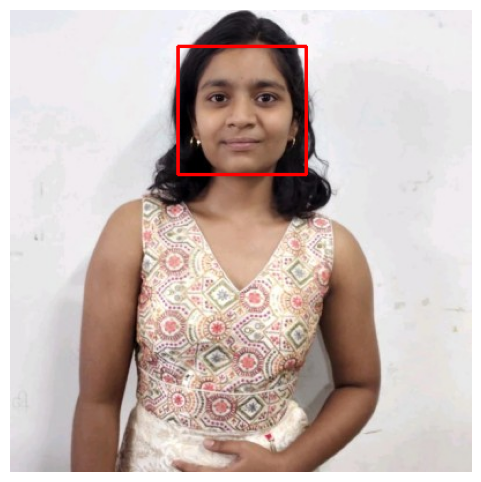

In [31]:
image_rgb = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB
)

for (x, y, w, h) in faces:

    cv2.rectangle(
        image_rgb,
        (x, y),
        (x + w, y + h),
        (255, 0, 0),
        2
    )

plt.figure(figsize=(6, 6))
plt.imshow(image_rgb)
plt.axis("off")
plt.show()

In [32]:
def predict_emotion(image_path):

    # Read image
    image = cv2.imread(image_path)

    # Convert to grayscale
    gray = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )

    # Detect faces
    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(30, 30)
    )

    if len(faces) == 0:
        print("❌ No face detected.")
        print("Please upload a clear front-facing photo.")
        return

    # Select largest face
    x, y, w, h = max(
        faces,
        key=lambda f: f[2] * f[3]
    )

    # Crop face
    face = gray[y:y+h, x:x+w]

    # Resize to CNN input
    face = cv2.resize(
        face,
        (48, 48)
    )

    # Normalize
    face = face.astype("float32") / 255.0

    # Add batch and channel dimensions
    face = np.expand_dims(face, axis=0)
    face = np.expand_dims(face, axis=-1)

    # CNN prediction
    prediction = model.predict(
        face,
        verbose=0
    )[0]

    # Get predicted emotion
    emotion_index = np.argmax(prediction)

    emotion = class_names[emotion_index]

    confidence = prediction[emotion_index] * 100

    print("================================")
    print("   FACIAL EMOTION RECOGNITION")
    print("================================")
    print()
    print("😊 Emotion:", emotion.upper())
    print("📊 Confidence:", round(confidence, 2), "%")

In [33]:
predict_emotion(image_path)

   FACIAL EMOTION RECOGNITION

😊 Emotion: NEUTRAL
📊 Confidence: 66.25 %


In [34]:
def show_emotion_probabilities(image_path):

    image = cv2.imread(image_path)

    gray = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )

    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(30, 30)
    )

    if len(faces) == 0:
        print("❌ No face detected.")
        return

    x, y, w, h = max(
        faces,
        key=lambda f: f[2] * f[3]
    )

    face = gray[y:y+h, x:x+w]

    face = cv2.resize(
        face,
        (48, 48)
    )

    face = face.astype("float32") / 255.0

    face = np.expand_dims(face, axis=0)
    face = np.expand_dims(face, axis=-1)

    prediction = model.predict(
        face,
        verbose=0
    )[0]

    predicted_index = np.argmax(prediction)

    print(
        "Predicted Emotion:",
        class_names[predicted_index].upper()
    )

    print(
        "Confidence:",
        round(
            prediction[predicted_index] * 100,
            2
        ),
        "%"
    )

    # Plot probabilities
    plt.figure(figsize=(9, 5))

    plt.bar(
        class_names,
        prediction * 100
    )

    plt.xlabel("Emotion")
    plt.ylabel("Probability (%)")
    plt.title("Facial Emotion Prediction")

    plt.xticks(rotation=30)

    plt.show()

In [35]:
def show_emotion_probabilities(image_path):

    image = cv2.imread(image_path)

    gray = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )

    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(30, 30)
    )

    if len(faces) == 0:
        print("❌ No face detected.")
        return

    x, y, w, h = max(
        faces,
        key=lambda f: f[2] * f[3]
    )

    face = gray[y:y+h, x:x+w]

    face = cv2.resize(
        face,
        (48, 48)
    )

    face = face.astype("float32") / 255.0

    face = np.expand_dims(face, axis=0)
    face = np.expand_dims(face, axis=-1)

    prediction = model.predict(
        face,
        verbose=0
    )[0]

    predicted_index = np.argmax(prediction)

    print(
        "Predicted Emotion:",
        class_names[predicted_index].upper()
    )

    print(
        "Confidence:",
        round(
            prediction[predicted_index] * 100,
            2
        ),
        "%"
    )

    # Plot probabilities
    plt.figure(figsize=(9, 5))

    plt.bar(
        class_names,
        prediction * 100
    )

    plt.xlabel("Emotion")
    plt.ylabel("Probability (%)")
    plt.title("Facial Emotion Prediction")

    plt.xticks(rotation=30)

    plt.show()

Predicted Emotion: NEUTRAL
Confidence: 66.25 %


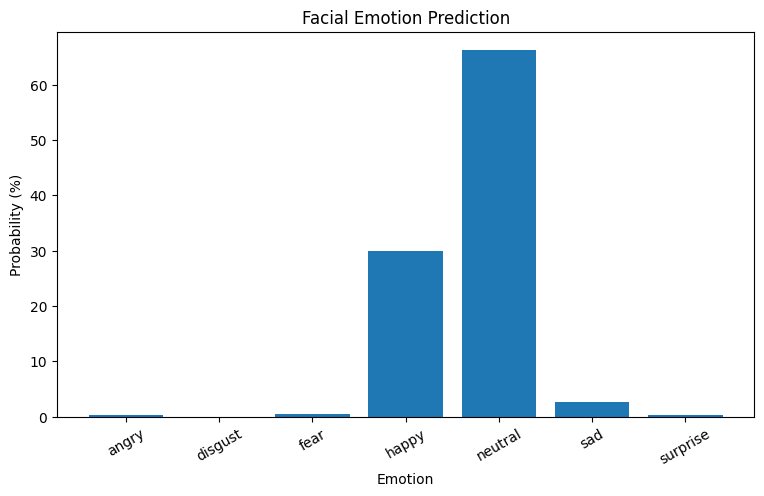

In [36]:
show_emotion_probabilities(image_path)

In [37]:
!pip install -q gradio

In [38]:
import gradio as gr
import cv2
import numpy as np

def emotion_detector(image):
    if image is None:
        return None, "Please upload an image."

    # Convert RGB image from Gradio to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    # Detect faces
    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(30, 30)
    )

    if len(faces) == 0:
        return image, "❌ No face detected. Please upload a clear front-facing image."

    # Select largest face
    x, y, w, h = max(faces, key=lambda f: f[2] * f[3])

    # Crop face
    face = gray[y:y+h, x:x+w]

    # Resize to CNN input size
    face = cv2.resize(face, (48, 48))

    # Normalize
    face = face.astype("float32") / 255.0

    # Add batch and channel dimensions
    face = np.expand_dims(face, axis=0)
    face = np.expand_dims(face, axis=-1)

    # Prediction
    prediction = model.predict(face, verbose=0)[0]

    predicted_index = np.argmax(prediction)
    emotion = class_names[predicted_index]
    confidence = prediction[predicted_index] * 100

    # Draw face rectangle
    output_image = image.copy()

    cv2.rectangle(
        output_image,
        (x, y),
        (x+w, y+h),
        (255, 0, 0),
        3
    )

    result = (
        f"😊 Emotion: {emotion.upper()}\n"
        f"📊 Confidence: {confidence:.2f}%"
    )

    return output_image, result

In [39]:
interface = gr.Interface(
    fn=emotion_detector,
    inputs=gr.Image(type="numpy", label="Upload Face Image"),
    outputs=[
        gr.Image(label="Detected Face"),
        gr.Textbox(label="Prediction")
    ],
    title="😊 Facial Emotion Recognition Using CNN",
    description="Upload a facial image to detect the predicted emotion."
)

interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ed90b02a53cb638e17.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [40]:
import gradio as gr
import cv2
import numpy as np
import matplotlib.pyplot as plt

def emotion_detector(image):

    if image is None:
        return None, "Please upload an image.", None

    # Convert RGB to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    # Detect faces
    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(30, 30)
    )

    if len(faces) == 0:
        return image, "❌ No face detected.", None

    # Select largest detected face
    x, y, w, h = max(
        faces,
        key=lambda f: f[2] * f[3]
    )

    # Crop face
    face = gray[y:y+h, x:x+w]

    # Resize
    face = cv2.resize(face, (48, 48))

    # Normalize
    face = face.astype("float32") / 255.0

    # Add dimensions
    face = np.expand_dims(face, axis=0)
    face = np.expand_dims(face, axis=-1)

    # CNN prediction
    prediction = model.predict(
        face,
        verbose=0
    )[0]

    # Find highest probability
    predicted_index = np.argmax(prediction)

    emotion = class_names[predicted_index]

    confidence = prediction[predicted_index] * 100

    # Draw rectangle
    output_image = image.copy()

    cv2.rectangle(
        output_image,
        (x, y),
        (x+w, y+h),
        (255, 0, 0),
        3
    )

    # Result text
    result = (
        f"😊 Emotion: {emotion.upper()}\n"
        f"📊 Confidence: {confidence:.2f}%"
    )

    # Create probability chart
    fig, ax = plt.subplots(figsize=(9, 5))

    probabilities = prediction * 100

    ax.bar(
        class_names,
        probabilities
    )

    ax.set_xlabel("Emotion")
    ax.set_ylabel("Probability (%)")
    ax.set_title("Emotion Prediction Probabilities")

    plt.xticks(rotation=30)
    plt.tight_layout()

    return output_image, result, fig

In [41]:
interface = gr.Interface(
    fn=emotion_detector,

    inputs=gr.Image(
        type="numpy",
        label="📷 Upload Face Image"
    ),

    outputs=[
        gr.Image(
            label="🔍 Detected Face"
        ),

        gr.Textbox(
            label="😊 Prediction"
        ),

        gr.Plot(
            label="📊 Emotion Probabilities"
        )
    ],

    title="😊 Facial Emotion Recognition Using CNN",

    description=(
        "Upload a facial image and the CNN model "
        "will predict the facial expression."
    )
)

interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://caf49d47ec868d8de9.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [42]:
test_loss, test_accuracy = model.evaluate(test_dataset)

print("================================")
print("       MODEL EVALUATION")
print("================================")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")

57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 111ms/step - accuracy: 0.5651 - loss: 1.1598
       MODEL EVALUATION
Test Loss     : 1.1598
Test Accuracy : 56.51%


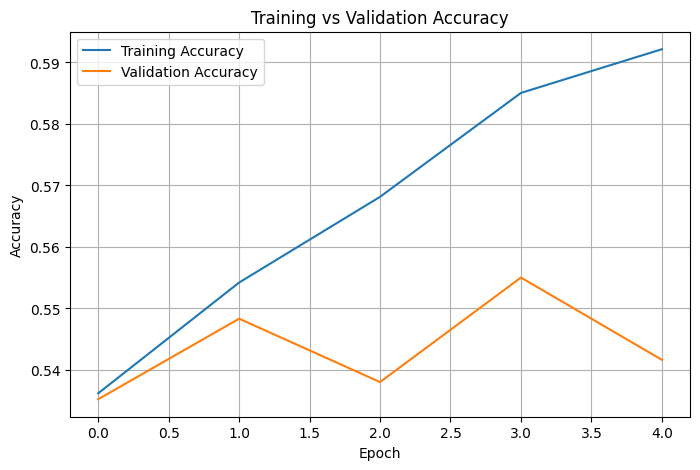

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid()

plt.show()

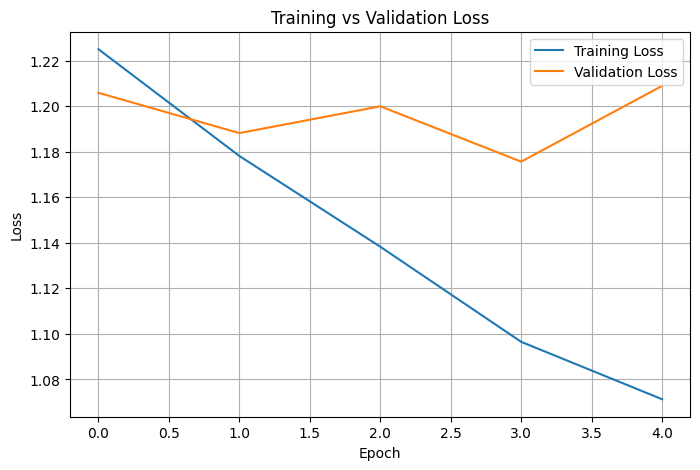

In [44]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid()

plt.show()

In [45]:
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

y_true = []
y_pred = []

for images, labels in test_dataset:

    predictions = model.predict(
        images,
        verbose=0
    )

    predicted_labels = np.argmax(
        predictions,
        axis=1
    )

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

cm = confusion_matrix(
    y_true,
    y_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[215   0  45  44  90  93   4]
 [ 25   3  11   2   3  10   1]
 [ 62   0 130  50  81 137  68]
 [ 25   0  16 737  38  49  14]
 [ 26   1  18  75 382 114  10]
 [ 53   0  51  70 137 277   6]
 [  8   0  48  40  24  12 284]]


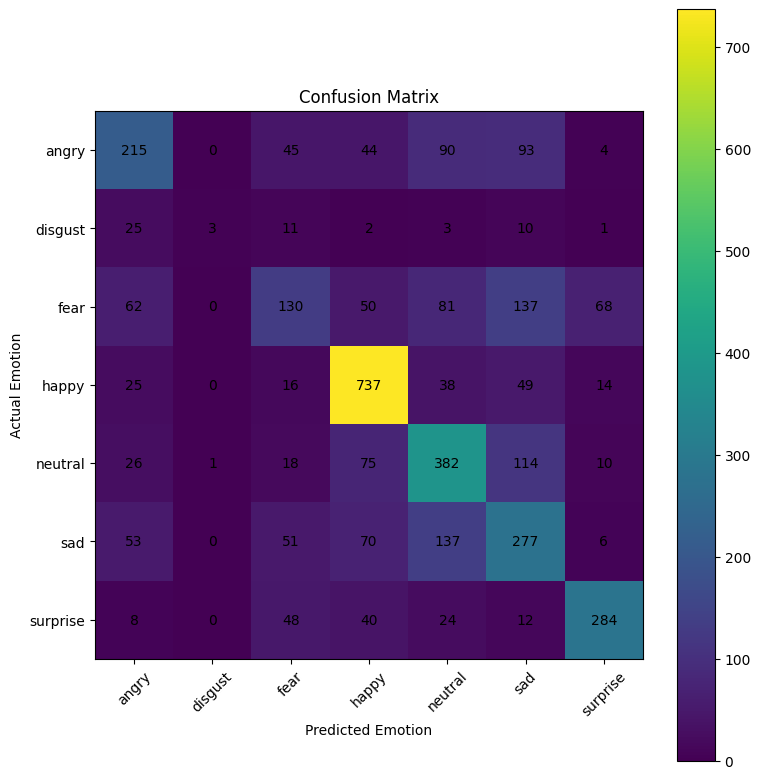

In [46]:
plt.figure(figsize=(8,8))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.xlabel("Predicted Emotion")
plt.ylabel("Actual Emotion")

plt.xticks(
    range(len(class_names)),
    class_names,
    rotation=45
)

plt.yticks(
    range(len(class_names)),
    class_names
)

plt.colorbar()

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()